<a href="https://colab.research.google.com/github/kjs0904/kjs/blob/main/%EC%9D%B4%EC%83%81%ED%83%90%EC%A7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

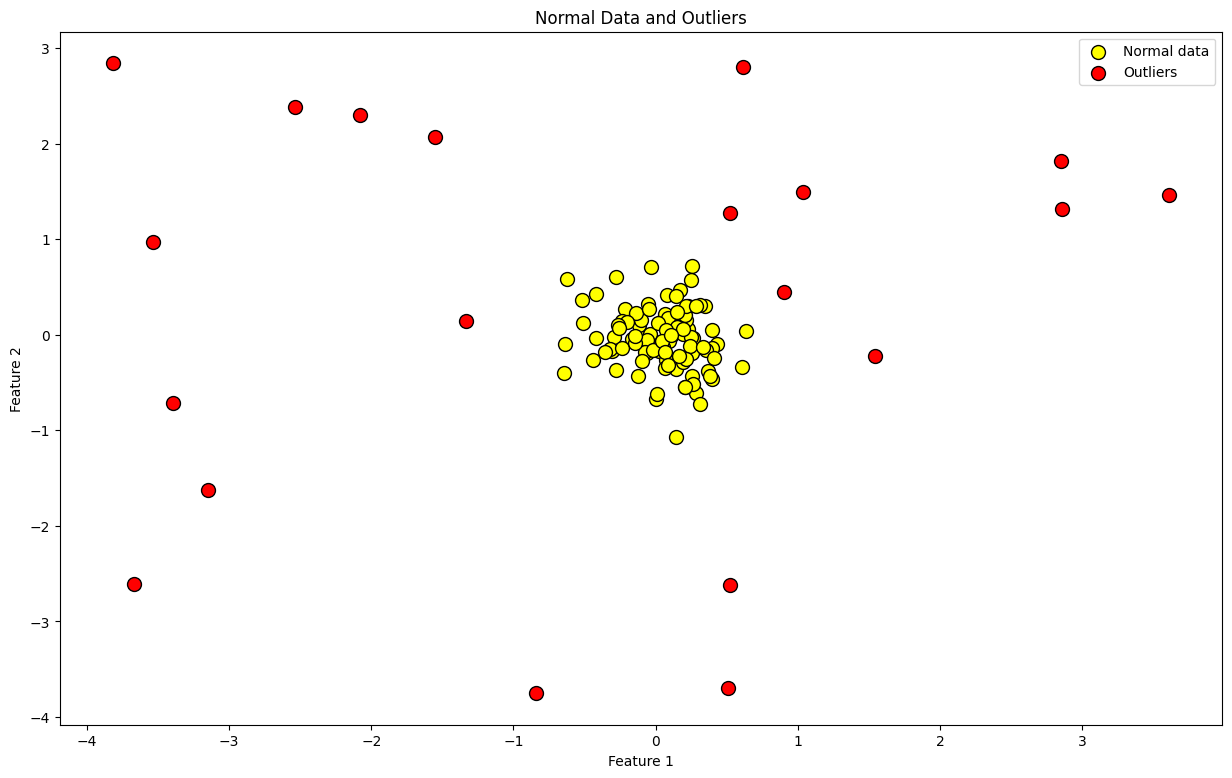

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

# 정상 데이터 (중앙에 뭉쳐있는 데이터 100개)
X_normal = 0.3 * np.random.randn(100, 2)

# 이상치 데이터 (넓게 퍼져있는 데이터 20개)
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

# 전체 데이터 결합
X = np.vstack([X_normal, X_outliers])

# 시각화
plt.figure(figsize=(15, 9))
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='yellow', edgecolor='k', s=100, label="Normal data")
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', edgecolor='k', s=100, label="Outliers")
plt.title("Normal Data and Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [2]:
from sklearn.ensemble import IsolationForest

# Isolation Forest 모델 생성
IForest = IsolationForest(
    n_estimators=100,     # 사용할 트리의 수
    max_samples='auto',   # 각 트리당 최대 샘플 수
    random_state=1234,    # 재현성을 위한 시드 고정
    contamination=0.15    # 전체 데이터셋에서 이상치가 차지하는 비율의 추정치
)

# 모델 학습
IForest.fit(X)

# 모든 데이터에 대한 이상치 점수 계산
# (점수가 낮을수록 평균 경로 길이가 짧아 이상치일 가능성이 높음)
scores_pred = IForest.decision_function(X)

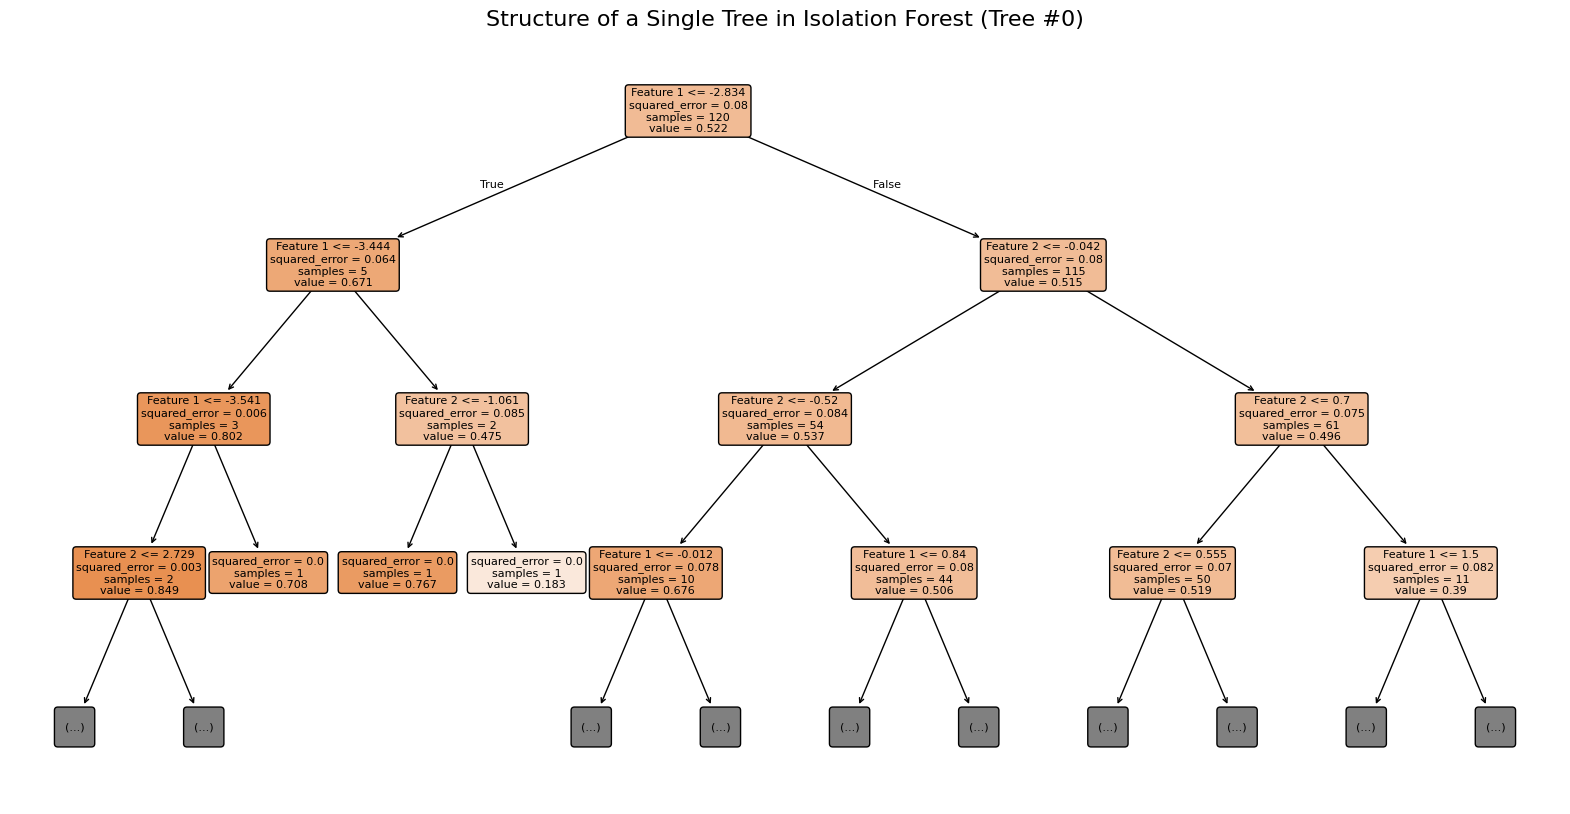

In [3]:
from sklearn.tree import plot_tree

# 1. Isolation Forest 내의 첫 번째 개별 트리 추출
selected_tree = IForest.estimators_[0]

# 2. 개별 의사결정 나무 시각화
plt.figure(figsize=(20, 10))
plot_tree(
    selected_tree,
    feature_names=["Feature 1", "Feature 2"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3 # 트리가 깊어 가독성이 떨어지면 max_depth 수치를 조정
)
plt.title("Structure of a Single Tree in Isolation Forest (Tree #0)", fontsize=16)
plt.show()

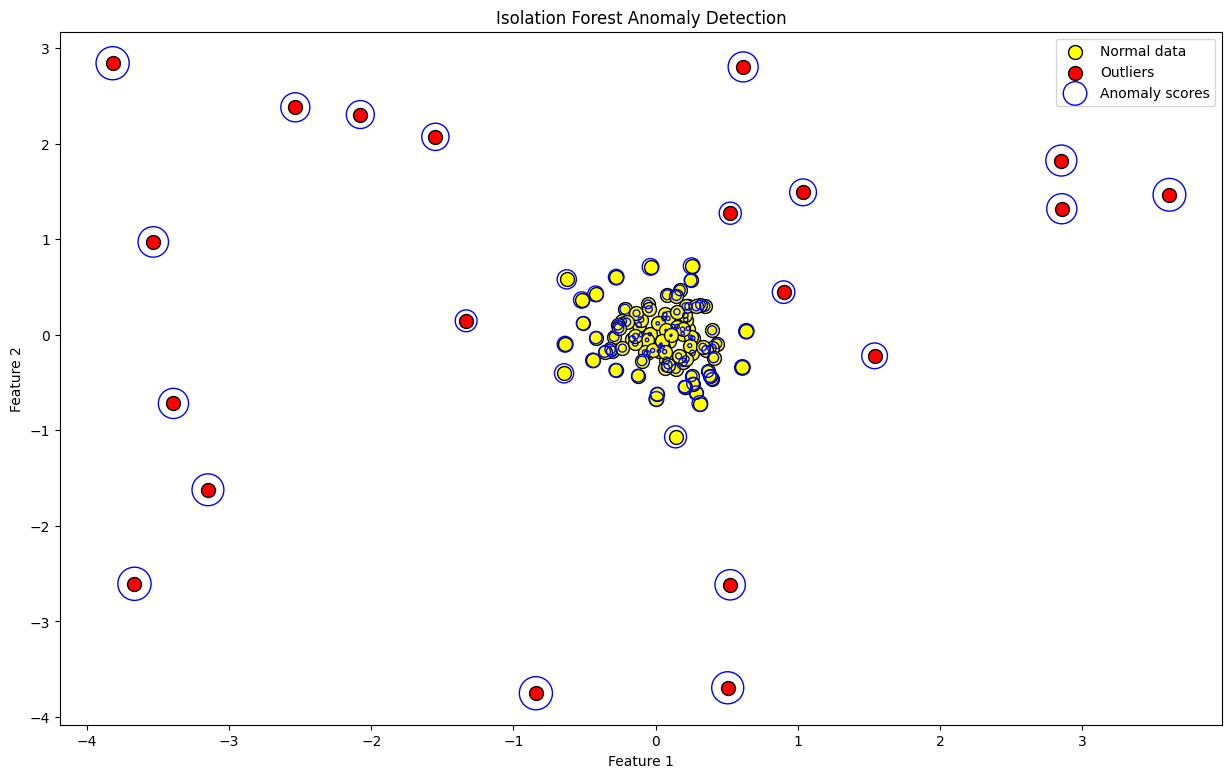

In [4]:
# 이상치 점수를 바탕으로 시각화
plt.figure(figsize=(15, 9))
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='yellow', edgecolor='k', s=100, label="Normal data")
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', edgecolor='k', s=100, label="Outliers")

# 이상치 점수에 따라 점의 크기를 조정
# 파란색 원이 클 수록 이상치일 확률이 큰 것을 의미
sizes = (scores_pred.max() - scores_pred) * 1500
plt.scatter(X[:, 0], X[:, 1], s=sizes, edgecolor='b', facecolors='none', label="Anomaly scores")

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

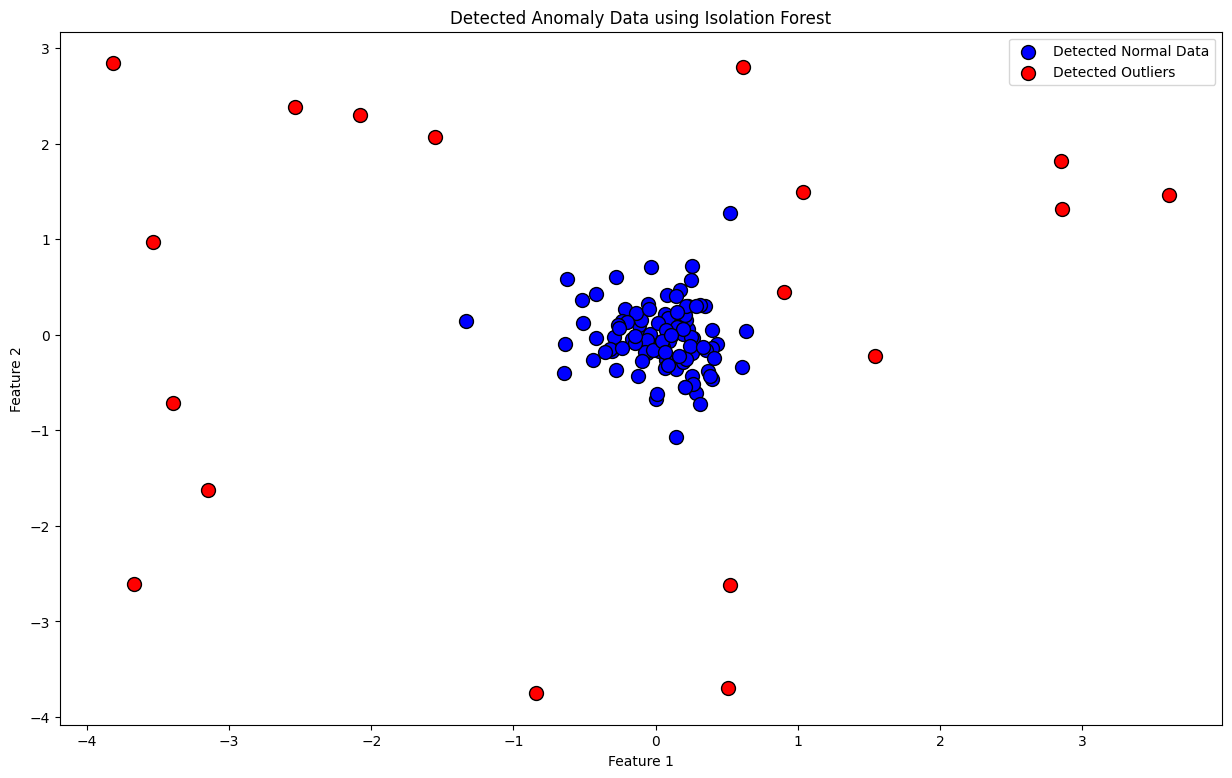

In [5]:
# 이상치 여부 예측
# 임계값(contamination) 0.15(=15%)를 기준으로 예측
# 정상 데이터는 1, 이상치는 -1로 반환됨
is_outlier = IForest.predict(X) == -1

# 정상 데이터와 이상치 데이터 분리
X_normal_detected = X[~is_outlier]
X_outliers_detected = X[is_outlier]

# 시각화
plt.figure(figsize=(15, 9))
plt.scatter(X_normal_detected[:, 0], X_normal_detected[:, 1], c='blue', edgecolor='k', s=100, label="Detected Normal Data")
plt.scatter(X_outliers_detected[:, 0], X_outliers_detected[:, 1], c='red', edgecolor='k', s=100, label="Detected Outliers")
plt.title("Detected Anomaly Data using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

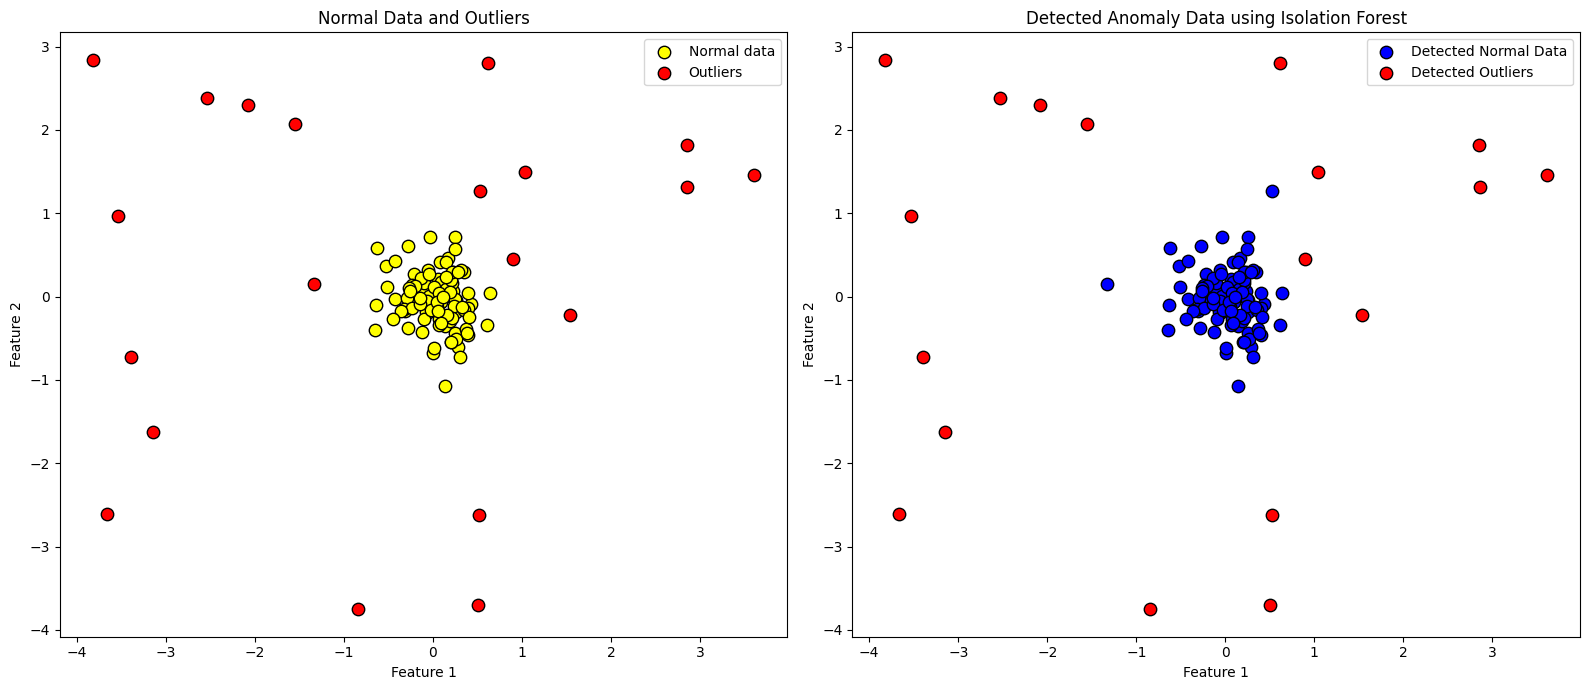

In [6]:
# 생성 데이터 vs 모델 예측 결과 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. 왼쪽: 생성된 원본 데이터 (Ground Truth)
axes[0].scatter(X_normal[:, 0], X_normal[:, 1], c='yellow', edgecolor='k', s=80, label="Normal data")
axes[0].scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', edgecolor='k', s=80, label="Outliers")
axes[0].set_title("Normal Data and Outliers")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

# 2. 오른쪽: Isolation Forest 모델 예측 결과
axes[1].scatter(X_normal_detected[:, 0], X_normal_detected[:, 1], c='blue', edgecolor='k', s=80, label="Detected Normal Data")
axes[1].scatter(X_outliers_detected[:, 0], X_outliers_detected[:, 1], c='red', edgecolor='k', s=80, label="Detected Outliers")
axes[1].set_title("Detected Anomaly Data using Isolation Forest")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()

plt.tight_layout()
plt.show()